In [190]:
import numpy as np
import pandas as pd
df=pd.read_csv('carpricesnew.csv')
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


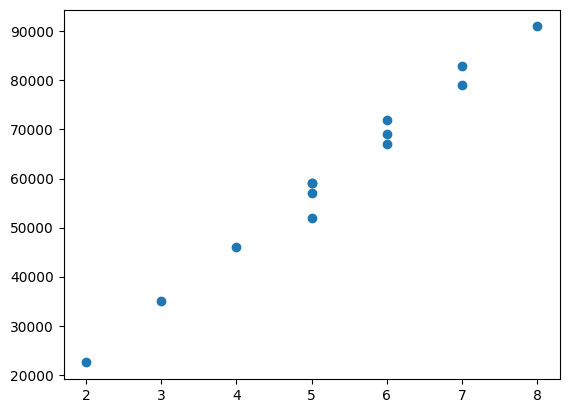

In [191]:
import matplotlib.pyplot as plt
plt.scatter(df['Age(yrs)'],df['Mileage'])


In [192]:
dummies=pd.get_dummies(df['Car Model'])
merged=pd.concat([df,dummies],axis='columns')
merged


,Car Model,Mileage,Sell Price($),Age(yrs),Audi A5,BMW X5,Mercedez Benz C class
0,BMW X5,69000,18000,6,False,True,False
1,BMW X5,35000,34000,3,False,True,False
2,BMW X5,57000,26100,5,False,True,False
3,BMW X5,22500,40000,2,False,True,False
4,BMW X5,46000,31500,4,False,True,False
5,Audi A5,59000,29400,5,True,False,False
6,Audi A5,52000,32000,5,True,False,False
7,Audi A5,72000,19300,6,True,False,False
8,Audi A5,91000,12000,8,True,False,False
9,Mercedez Benz C class,67000,22000,6,False,False,True


In [193]:
final=merged.drop(['Car Model','Audi A5'],axis='columns')
final

,Mileage,Sell Price($),Age(yrs),BMW X5,Mercedez Benz C class
0,69000,18000,6,True,False
1,35000,34000,3,True,False
2,57000,26100,5,True,False
3,22500,40000,2,True,False
4,46000,31500,4,True,False
5,59000,29400,5,False,False
6,52000,32000,5,False,False
7,72000,19300,6,False,False
8,91000,12000,8,False,False
9,67000,22000,6,False,True


In [194]:
X = final[['Age(yrs)', 'Mileage', 'BMW X5', 'Mercedez Benz C class']]
X

,Age(yrs),Mileage,BMW X5,Mercedez Benz C class
0,6,69000,True,False
1,3,35000,True,False
2,5,57000,True,False
3,2,22500,True,False
4,4,46000,True,False
5,5,59000,False,False
6,5,52000,False,False
7,6,72000,False,False
8,8,91000,False,False
9,6,67000,False,True


In [195]:
y = df['Sell Price($)']
y

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: Sell Price($), dtype: int64

In [196]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=10)
X_train

,Age(yrs),Mileage,BMW X5,Mercedez Benz C class
6,5,52000,False,False
8,8,91000,False,False
2,5,57000,True,False
12,5,59000,False,True
5,5,59000,False,False
10,7,83000,False,True
1,3,35000,True,False
0,6,69000,True,False
4,4,46000,True,False
9,6,67000,False,True


In [197]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [198]:
reg.predict(X_test)

array([42227.72902772, 24434.07043407, 19085.43933545])

In [199]:
Y_test

3     40000
7     19300
11    21000
Name: Sell Price($), dtype: int64

In [200]:
reg.score(X_test,Y_test)

0.8675370464377559

In [201]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(reg, X_train, Y_train, cv=5)

print(scores.mean())

0.5163272792798772


In [202]:
reg.fit(X_train, Y_train)
print(reg.score(X_test, Y_test))

0.8675370464377559


In [203]:
reg.predict([[4,45000,0,1]])

C:\Users\Taimour Khokhar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36871.03077102])

In [204]:
reg.predict([[7,86000,1,0]])

C:\Users\Taimour Khokhar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([12537.34643736])